# STAT 207 Project 02 - Analyzing Poverty and Income Disparities Across U.S. Counties Using Bootstrapping Methods

Dulf Vincent Genis

### Contribution Report

If you open this document, you should edit and complete the contribution report.  Please complete this report if you work individually, in a group and your submission is the one to be graded, or in a group but someone else should be graded.

In this contribution report below you should list of the following:
1. The netID for the project submission to be graded.  (Some groups have each member create their own version of the document, but only one needs to be submitted for grading.  Other groups have only one member compose and submit the project.)
2. Names and netIDs of each team member.
3. Contributions to report of each team member.

*For example:*

*<u>Teammates:</u>*

*doe105 should be graded.  John Smith (smith92) & Jane Doe (doe105) worked together on all parts of this project*, 

OR

*doe105 should be graded*

<i>1. John Smith (smith92) completed parts 1 - 3</i>

<i>2. Jane Doe (doe105) completed parts 4 - 5</i>

<i>We both reviewed the full document before submission.</i>

dgeni2 should be graded. Dulf Vincent Genis (dgeni2) completed all parts (1 - 4). I reviewed the full document before submission.

## 1. Introduction

**Dataset Introduction**: The dataset includes comprehensive income and poverty-related data for all counties in the United States and its territories. Key variables include poverty rates for all ages and children, median household income, deep poverty rates, and per capita income.

**Population and Sample**: The dataset represents the entire population of U.S. counties. For inferential analysis, we'll treat the full dataset as the population and use bootstrapping to simulate sampling distributions, allowing us to make inferences about the parameters.

**Research Questions**:
- What is the average poverty rate among U.S. counties in the dataset, and what is a reasonable range (confidence interval) for this average across all U.S. counties?
- Is there a significant difference in median household income between counties with poverty rates above 20% and those below 20%?

**Motivation**: Understanding the relationship between poverty rates and median household income across counties is crucial for informing policymakers and stakeholders. Identifying significant differences can help in allocating resources effectively to areas most in need, ultimately contributing to efforts aimed at reducing economic disparities and improving social welfare.

Variables in the data include but are not limited to:

- **Deep_Pov_Children**: Deep poverty for children, 2017-21
- **Deep_Pov_All**: Deep poverty, 2017-21
- **Median_HH_Inc_ACS**: Median household income (In 2021 dollars), 2017-21
- **PerCapitaInc**: Per capita Income in the past 12 months (In 2021 inflation adjusted dollars), 2017-21
- **Poverty_Rate_0_17_ACS**: Poverty rate for children age 0-17, 2017-21
- **Poverty_Rate_ACS**: Poverty rate, 2017-21
- **MedHHInc**: Median household income (In 2021 dollars), 2021
- **POV017**: Number of people age 0-17 in poverty, 2021
- **NumAll_inPOV_ACS**: Number of people of all ages in poverty , 2017-21
- **POVALL**: Number of people of all ages in poverty , 2021
- **PCTPOV017**: Poverty rate for children age 0-17, 2021
- **PCTPOVALL**: Poverty rate, 2021
- **Num_inPOV_0_17_ACS**: Number of people age 0-17 in poverty, 2017-21

Variables of interest:
- **Median_HH_Inc_ACS**: Median household income (In 2021 dollars), 2017-21
- **Poverty_Rate_ACS**: Poverty rate, 2017-21

### **Additional Information: Data Download for the Atlas of Rural and Small-Town America**

This project utilizes data from the *Atlas of Rural and Small-Town America*, provided by the USDA Economic Research Service. Below are key details about the data:

### **Notes:**
1. All variables in the atlas are available in a downloadable workbook, organized into separate tabs by data category: People, Jobs, County Classifications, Income, and Veterans. Some additional indicators in the spreadsheet are not in the atlas, identified by "n" in the "Map" column in the Variable Name Lookup tab.
2. The **Variable Name Lookup** tab connects the short names used in row 1 of the dataset to more detailed descriptions of each indicator.
3. The **Documentation** tab provides definitions and sources for all data.
4. Some county listings may vary slightly due to differences in configurations used by various Federal data sources, particularly in Alaska and Virginia.
5. Blank data cells for specific counties indicate unavailable, inapplicable, or suppressed values.
6. County-level **Census of Agriculture** data are now provided by the National Agricultural Statistics Service (NASS) and are no longer included in the atlas.

For detailed data definitions, sources, and the full version history, see the **Documentation** tab in the dataset, and link here: https://catalog.data.gov/dataset/atlas-of-rural-and-small-town-america.

### **Data Sources:**
- U.S. Bureau of the Census
- Bureau of Labor Statistics
- Bureau of Economic Analysis

For further information or inquiries, contact:  
**Austin Sanders**  
USDA Economic Research Service  
Email: austin.sanders@usda.gov

## 2. Confidence Interval Analytical Tasks

### (2a) Research Question:
- What is the average poverty rate among U.S. counties in the dataset? What is a reasonable range (confidence interval) for this average across all U.S. counties?

### (2b) Dataset cleaning
#### (2b.1) Import Libraries and Load Data

In [1088]:
#Imports here
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [1089]:
df_initial = pd.read_csv("Income.csv", encoding='ISO-8859-1')
df_initial

,FIPS,State,County,Attribute,Value
0,0,US,United States,Median_HH_Inc_ACS,69021.000000
1,0,US,United States,PerCapitaInc,37638.000000
2,0,US,United States,Poverty_Rate_0_17_ACS,17.046705
3,0,US,United States,Poverty_Rate_ACS,12.631850
4,0,US,United States,Deep_Pov_All,5.777385
...,...,...,...,...,...
42155,72153,PR,Yauco,Poverty_Rate_ACS,46.439216
42156,72153,PR,Yauco,Deep_Pov_All,25.803745
42157,72153,PR,Yauco,Deep_Pov_Children,29.142950
42158,72153,PR,Yauco,NumAll_inPOV_ACS,16048.000000


#### (2b.2) Reshape the Data
The data is currently in a long format with attributes or prospective variables in rows. We'll pivot the data to have one row per county, with attributes as columns and clear variables.

In [1090]:
df_rename = df_initial.rename(columns={'Attribute': 'Index'})

df_reframe = df_rename.pivot_table(index=['FIPS', 'State', 'County'], columns='Index', values='Value').reset_index()

df_reframe

Index,FIPS,State,County,Deep_Pov_All,Deep_Pov_Children,MedHHInc,Median_HH_Inc_ACS,NumAll_inPOV_ACS,Num_inPOV_0_17_ACS,PCTPOV017,PCTPOVALL,POV017,POVALL,PerCapitaInc,Poverty_Rate_0_17_ACS,Poverty_Rate_ACS
0,0,US,United States,5.777385,7.691715,69717.0,69021.0,40661636.0,12443424.0,16.9,12.8,12243219.0,41393176.0,37638.0,17.046705,12.631850
1,1000,AL,Alabama,7.077316,10.390582,53990.0,54943.0,769819.0,245896.0,22.7,16.3,250327.0,800848.0,30458.0,22.261936,15.785127
2,1001,AL,Autauga,6.250216,8.592895,66444.0,62660.0,7847.0,2560.0,16.1,10.7,2199.0,6296.0,30968.0,18.673864,13.578474
3,1003,AL,Baldwin,4.043401,5.503712,65658.0,64346.0,20598.0,5449.0,16.4,10.8,8207.0,25526.0,35384.0,11.299822,9.204905
4,1005,AL,Barbour,12.826966,26.729258,38649.0,36422.0,5890.0,2283.0,35.1,23.0,1776.0,5089.0,21325.0,43.744012,26.471910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3269,72145,PR,Vega Baja,22.362745,33.370684,NaN,21507.0,23520.0,5180.0,NaN,NaN,NaN,NaN,12361.0,52.765611,43.361233
3270,72147,PR,Vieques,32.271252,56.775851,NaN,14942.0,4425.0,1339.0,NaN,NaN,NaN,NaN,8834.0,85.998715,53.204280
3271,72149,PR,Villalba,28.576575,43.085946,NaN,20722.0,9881.0,2456.0,NaN,NaN,NaN,NaN,12179.0,55.402662,44.494979
3272,72151,PR,Yabucoa,26.283745,42.056583,NaN,17267.0,16335.0,3646.0,NaN,NaN,NaN,NaN,10507.0,66.122597,52.622254


#### (2b.3) Rename Columns for Clarity

In [1091]:
df_rename_2 = df_reframe.rename(columns={'FIPS': 'FIPS_Code', 'State': 'State_Name', 'County': 'County_Name', 'Deep_Pov_All': 'Deep_Poverty_All_Ages', 'Deep_Pov_Children': 'Deep_Poverty_Children', 'MedHHInc': 'Median_Household_Income_Census', 'Median_HH_Inc_ACS': 'Median_Household_Income_ACS', 'NumAll_inPOV_ACS': 'Number_All_Ages_in_Poverty_ACS', 'Num_inPOV_0_17_ACS': 'Number_Children_in_Poverty_ACS', 'PCTPOV017': 'Percent_Children_in_Poverty', 'PCTPOVALL': 'Percent_All_Ages_in_Poverty', 'POV017': 'Number_Children_in_Poverty', 'POVALL': 'Number_All_Ages_in_Poverty', 'PerCapitaInc': 'Per_Capita_Income', 'Poverty_Rate_0_17_ACS': 'Poverty_Rate_Children_ACS', 'Poverty_Rate_ACS': 'Poverty_Rate_All_Ages_ACS'})
df_rename_2

Index,FIPS_Code,State_Name,County_Name,Deep_Poverty_All_Ages,Deep_Poverty_Children,Median_Household_Income_Census,Median_Household_Income_ACS,Number_All_Ages_in_Poverty_ACS,Number_Children_in_Poverty_ACS,Percent_Children_in_Poverty,Percent_All_Ages_in_Poverty,Number_Children_in_Poverty,Number_All_Ages_in_Poverty,Per_Capita_Income,Poverty_Rate_Children_ACS,Poverty_Rate_All_Ages_ACS
0,0,US,United States,5.777385,7.691715,69717.0,69021.0,40661636.0,12443424.0,16.9,12.8,12243219.0,41393176.0,37638.0,17.046705,12.631850
1,1000,AL,Alabama,7.077316,10.390582,53990.0,54943.0,769819.0,245896.0,22.7,16.3,250327.0,800848.0,30458.0,22.261936,15.785127
2,1001,AL,Autauga,6.250216,8.592895,66444.0,62660.0,7847.0,2560.0,16.1,10.7,2199.0,6296.0,30968.0,18.673864,13.578474
3,1003,AL,Baldwin,4.043401,5.503712,65658.0,64346.0,20598.0,5449.0,16.4,10.8,8207.0,25526.0,35384.0,11.299822,9.204905
4,1005,AL,Barbour,12.826966,26.729258,38649.0,36422.0,5890.0,2283.0,35.1,23.0,1776.0,5089.0,21325.0,43.744012,26.471910
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3269,72145,PR,Vega Baja,22.362745,33.370684,NaN,21507.0,23520.0,5180.0,NaN,NaN,NaN,NaN,12361.0,52.765611,43.361233
3270,72147,PR,Vieques,32.271252,56.775851,NaN,14942.0,4425.0,1339.0,NaN,NaN,NaN,NaN,8834.0,85.998715,53.204280
3271,72149,PR,Villalba,28.576575,43.085946,NaN,20722.0,9881.0,2456.0,NaN,NaN,NaN,NaN,12179.0,55.402662,44.494979
3272,72151,PR,Yabucoa,26.283745,42.056583,NaN,17267.0,16335.0,3646.0,NaN,NaN,NaN,NaN,10507.0,66.122597,52.622254


#### (2b.4) Organize and filter for variables of interest

In [1092]:
df_interest = df_rename_2[['FIPS_Code', 'State_Name', 'County_Name','Median_Household_Income_ACS', 'Poverty_Rate_All_Ages_ACS']]
df_interest

Index,FIPS_Code,State_Name,County_Name,Median_Household_Income_ACS,Poverty_Rate_All_Ages_ACS
0,0,US,United States,69021.0,12.631850
1,1000,AL,Alabama,54943.0,15.785127
2,1001,AL,Autauga,62660.0,13.578474
3,1003,AL,Baldwin,64346.0,9.204905
4,1005,AL,Barbour,36422.0,26.471910
...,...,...,...,...,...
3269,72145,PR,Vega Baja,21507.0,43.361233
3270,72147,PR,Vieques,14942.0,53.204280
3271,72149,PR,Villalba,20722.0,44.494979
3272,72151,PR,Yabucoa,17267.0,52.622254


#### (2b.5) Handling missing values

In [1093]:
df_interest.isnull().sum()

Index
FIPS_Code                      0
State_Name                     0
County_Name                    0
Median_Household_Income_ACS    1
Poverty_Rate_All_Ages_ACS      0
dtype: int64

In [1094]:
df_clean = df_interest.dropna()
df_clean = df_clean[df_clean['State_Name'] != 'US'] # Filtering out the overall US unit of observation to just look at counties

In [1095]:
df_clean.isnull().sum()

Index
FIPS_Code                      0
State_Name                     0
County_Name                    0
Median_Household_Income_ACS    0
Poverty_Rate_All_Ages_ACS      0
dtype: int64

### (2c) Descriptive analytics

#### (2c.1) Sample size

In [1096]:
df_clean.shape[0]

3272

My sample size is 3272 units of observation, or U.S. counties.

#### (2c.2) Numerical summary

In [1097]:
mean_poverty_rate = df_clean['Poverty_Rate_All_Ages_ACS'].mean()
mean_poverty_rate

15.143983163996332

#### (2c.3) Numerical summary interpretation

The average poverty rate across U.S. counties is approximately 15.14%

### (2d) Create a confidence interval

#### (2d.1) Selecting an appropriate confidence level
I will be using a 95% confidence interval, which corresponds to the range between the 2.5th and 97.5th percentiles of the sampling distribution.

#### (2d.2) Simulating a sampling distribution for my proportion

In [1098]:
simulated_statistics = []
for i in range(10000):
    df_sample = df_clean.sample(3272, replace = True)
    simulated_statistics.append(df_sample['Poverty_Rate_All_Ages_ACS'].mean())
simulated_statistics = pd.DataFrame({'mean': simulated_statistics})
simulated_statistics

,mean
0,15.525747
1,15.317303
2,15.360664
3,15.125755
4,14.878778
...,...
9995,15.100055
9996,15.180468
9997,15.036242
9998,15.057098


#### (2d.3) Using this simulated sampling distribution to estimate my confidence interval

In [1099]:
# Using a 95% confidence interval and range between the 2.5th and 97.5th percentiles

lower_bound = simulated_statistics['mean'].quantile(0.025)
upper_bound = simulated_statistics['mean'].quantile(0.975)

lower_bound

14.88041232478685

In [1100]:
upper_bound

15.416082313058244

### (2e) Interpreting my confidence interval & confidence level

Based on the data and the analysis, I am 95% confident that the true mean poverty rate among all U.S. counties is between 14.88% and 15.42%, so this is our confidence interval. This means that this range is likely to contain the true mean, and from our actual average poverty rate calculation 15.14% is well within 14.88% and 15.42%.

The 95% confidence interval provides a range of values that are likely to contain the true population parameter. So, in this case, based on the sample distribution data, I am 95% confident that the true average poverty rate for all U.S. counties lies between 14.88% and 15.42%. This means that if I were to repeat the sampling process many times, approximately 95% of the calculated intervals would have the true population parameter.

The 95% confidence level means I'm 95% confident that this range has the true average poverty rate. It doesn’t mean that there’s a 95% chance the true value is in this specific interval, but that the process I used is reliable.

## 3. Hypothesis Testing Analytical Tasks

### (3a) Research Question:
- How does the median household income differ between counties with high poverty rates and those with low poverty rates? Is there a significant difference in median household income between counties with poverty rates above 20% and those below 20%?

### (3b) Dataset cleaning

#### (3b.1) Create Additional Variables
Create a binary categorical variable for high and low poverty rates.

"High poverty" is defined as an areawide poverty rate of 20 percent or more, based on the U.S. Department of Commerce, Bureau of the Census’s Official Poverty Measure (OPM).

https://www.ers.usda.gov/data-products/poverty-area-measures/background-and-uses/#:~:text=%22High%20poverty%22%20is%20defined%20as,Official%20Poverty%20Measure%20(OPM)

In [1101]:
poverty_threshold = 20

# 1 if poverty rate > 20%, else 0
df_clean['High_Poverty'] = np.where(df_clean['Poverty_Rate_All_Ages_ACS'] >= poverty_threshold, 1, 0)

df_clean['High_Poverty'].value_counts()

High_Poverty
0    2688
1     584
Name: count, dtype: int64

### (3c) Descriptive analytics

#### (3c.1) Numerical summaries

In [1102]:
income_by_poverty = df_clean.groupby('High_Poverty')['Median_Household_Income_ACS'].describe()
income_by_poverty

,count,mean,std,min,25%,50%,75%,max
High_Poverty,,,,,,,,
0,2688.0,61569.336682,14627.006678,31594.0,52201.0,58511.5,67415.25,156821.0
1,584.0,38749.494863,9949.689198,12856.0,33954.0,40006.0,44502.50,79583.0


#### (3c.2) Visualization

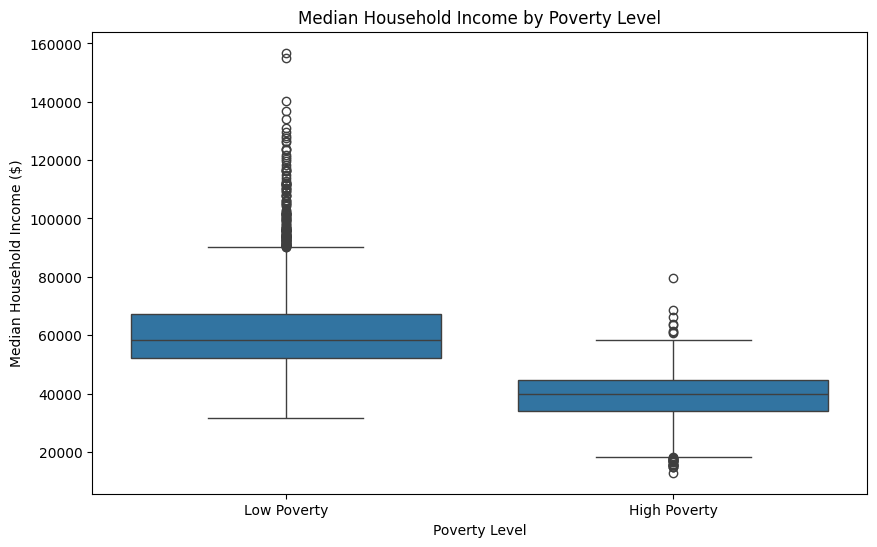

In [1103]:
plt.figure(figsize=(10,6))
sns.boxplot(x='High_Poverty', y='Median_Household_Income_ACS', data=df_clean)
plt.xticks([0,1], ['Low Poverty', 'High Poverty'])
plt.title('Median Household Income by Poverty Level')
plt.xlabel('Poverty Level')
plt.ylabel('Median Household Income ($)')
plt.show()

#### (3c.3) Interpretation

#### (3d.4) The most appropriate measure of center to describe my variable of interest
The median is the best measure of center here because it’s less impacted by extreme values or outliers than the mean. Especially in the low-poverty group, incomes vary and pretty widely with a lot of outliers as we can see on the visualization, so the median ($58511.5) gives a clearer picture of typical income than the mean, which can be pulled up by higher incomes. Showing what the, we can say, "middle" household earns makes it more reliable for skewed data like this.

### (3d) Perform a hypothesis test

#### (3d.1) Stating my Hypotheses
Null Hypothesis (H0): There is no difference in median household income between counties with high poverty rates (≥20%) and low poverty rates (<20%).
- H0: μ high poverty ​= μ low poverty

Alternative Hypothesis (Ha): There is a significant difference in median household income between counties with high poverty rates and those with low poverty rates.
- HA: μ high poverty ​!= μ low poverty

Here, μ represents the mean median household income of counties. The parameter of interest is the difference in mean median household income between high-poverty counties and low-poverty counties.

#### (3d.2) Select a significance level
We will use a significance level of 0.05. This means we are willing to accept a 5% chance of rejecting the null hypothesis if it is true.

#### (3d.3) Check the Conditions for This Test
- Randomness: The dataset represents all counties in the U.S., so it's not a random sample. Albeit, we can still apply bootstrapping methods to simulate the distribution and make inferences about the population.
- Independence: Each county’s income data is pretty much under the assumption to be independent of the others.
- Sample Size: Both high-poverty and low-poverty groups are large enough to allow us to use bootstrapping techniques.

#### (3d.4) Simulate a sampling distribution for your statistic of interest

In [1104]:
# Data for low and high poverty counties
income_low_poverty = df_clean[df_clean['High_Poverty'] == 0]['Median_Household_Income_ACS']
income_high_poverty = df_clean[df_clean['High_Poverty'] == 1]['Median_Household_Income_ACS']

In [1105]:
income_low_poverty.shape[0]

2688

In [1106]:
income_high_poverty.shape[0]

584

In [1107]:
simulated_diffs = []
for i in range(10000):
    sample_low = income_low_poverty.sample(2688, replace=True)
    sample_high = income_high_poverty.sample(584, replace=True)
    diff = sample_low.mean() - sample_high.mean()
    simulated_diffs.append(diff)
simulated_diffs = pd.DataFrame({'mean_diff': simulated_diffs})
simulated_diffs

,mean_diff
0,22830.436399
1,22175.994593
2,23197.728856
3,21898.306537
4,22945.096864
...,...
9995,22587.657244
9996,22934.572315
9997,22769.616734
9998,22820.311532


No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


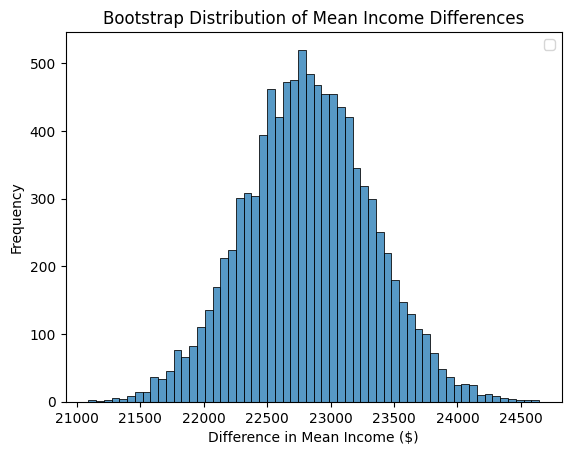

In [1108]:
sns.histplot(simulated_diffs['mean_diff'])
plt.title('Bootstrap Distribution of Mean Income Differences')
plt.xlabel('Difference in Mean Income ($)')
plt.ylabel('Frequency')
plt.legend()
plt.show()

#### (3d.5) Calculate a p-value for this test based on the sampling distribution

In [1111]:
observed_diff = income_low_poverty.mean() - income_high_poverty.mean()

extreme_diffs = simulated_diffs[simulated_diffs['mean_diff'] >= observed_diff]
p_value = len(extreme_diffs) / len(simulated_diffs)
p_value

0.4989

#### (3d.5) Evaluate your results to make a decision and state a conclusion

In [1110]:
p_value < 0.05

False

The p-value is more than our significance level of 0.05, which means we fail to reject the null hypothesis and there is no significant difference in median household income between high-poverty and low-poverty counties.

### (3e) Interpret your significance level & p-value
#### (3e.1) Provide a formal interpretation for both of these values

The significance level of 0.05 means we are willing to accept a 5% risk of rejecting the null hypothesis when it’s actually true, and/or there's a 5% chance we could say there's a difference when there really isn't, which would be a Type 1 error or false positive.

The p-value tells us the likelihood of observing our data, or something more extreme, if the null hypothesis is true.

- If p < 0.05, we reject the null hypothesis, meaning the result is statistically significant, and the observed difference is unlikely due to chance.

- If p ≥ 0.05, we fail to reject the null hypothesis, meaning there is no significant evidence of a difference, and the result could be due to chance or randomness.

The p-value is greater than our 0.05 significance level, so we do not reject the null hypothesis, concluding that there is no significant difference in median household income between high-poverty and low-poverty counties.

## Any other type of analysis/question you want to explore with this dataset.

<u>Why?</u>: Sometimes undergraduate students will put the research projects that they did for their classes on their resumes when applying for graduate schools, internships, and jobs. If you're interested in showcasing cool analyses to write on your resume, this section could help with that. **(This section is not worth any points though).**

## 4. Conclusion

### (4a) Summarization
In this project, I looked at how poverty rates and median household incomes differ across U.S. counties. Using a bootstrapping methods, I estimated that the average poverty rate in these counties is between 14.88% and 15.42%, with 95% confidence. This gives policymakers and others a good idea of the poverty situation in different areas. I also ran a hypothesis test to check if counties with higher poverty rates (20% or more) have significantly different median household incomes compared to counties with lower poverty rates (less than 20%). The test gave me a p-value of 0.49890, meaning we did not reject the null hypothesis at the 0.05 significance level. This means that, based on the data, there’s no statistically significant difference in median household incomes between high-poverty and low-poverty counties.

### (4b) Limitations
While this analysis gives us useful insights, there are some important limitations and struggles that I went through to keep in mind especially with my methodoloy. First, the dataset, although it covers all U.S. counties, may have outdated or inaccurate information that could affect the findings. Conditions in counties can change quickly due to things like economic shifts, new policies, or unexpected events such as natural disasters or pandemics. Also, the assumption that counties are completely independent of each other might not hold up, if that's the way to put it, as neighboring counties, or those within the same state, may have similar economic factors or be influenced by shared regional policies. Lastly, using bootstrapping assumes that the data distribution reflects the population accurately. Since we used the entire dataset as our sample, any biases could carry over to the results, and I personally struggled with my bootstrapping methodology as the p-value calculation shows that there's no significant different income between low and high poverty counties when my visualizations do show that there is, so, it should be viewed with some caution. It is data and an analysis with a lot of potential, and a lot of room for improvement that would make it extremely useful for policymakers going forward.

### (4c) Future Work
For future work or research, it could be helpful to look into other reasons why poverty and income differences exist. Things like education, job opportunities, or access to services might play a big role, and it's just a matter of finding data that has tracked those variables efficiently. It would also be interesting to see how these factors change over time by looking at data from different years, which could show whether policies to reduce poverty are actually working. Maybe on a more local scale, studying cities or neighborhoods might highlight specific areas that need more help. This kind of focused research could help decision-makers come up with better ways to fight poverty and raise income levels where it may see more tangible change, etc.